# 02 — Baseline Models

**Baselines first — always.**

Before fitting any ML model, we need to know what 'good' looks like. A model
that doesn't beat a simple rule isn't worth deploying.

We evaluate three baselines in increasing sophistication:

| Model | Description | What it captures |
|-------|-------------|------------------|
| Naive | Last observed value | Nothing — pure persistence |
| Seasonal naive (m=7) | Same day last week | Weekly seasonality |
| Moving average (28d) | Mean of last 28 days | Trend-smoothing |

The seasonal naive is typically the hardest to beat and sets the true floor
for MASE (by definition, MASE = 1.0 for seasonal naive vs. itself).

**Before running:** `make data-m5` from the repo root.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path("..").resolve().parent.parent
sys.path.insert(0, str(REPO_ROOT / "src"))
sys.path.insert(0, str(Path("..").resolve() / "src"))

import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from commerce_ml.viz.plotting import apply_style, PALETTE, plot_metrics_comparison

apply_style()

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

print("Setup complete.")

Setup complete.


## 1. Load and split data

In [2]:
from forecasting.data import load_m5_long, train_test_split

df = load_m5_long(store_id="CA_1")
train, test = train_test_split(df, test_days=28)

print(
    f"Train: {train['date'].min().date()} to {train['date'].max().date()} ({train['date'].nunique()} days)"
)
print(
    f"Test:  {test['date'].min().date()} to {test['date'].max().date()} ({test['date'].nunique()} days)"
)
print(f"SKUs:  {df['id'].nunique():,}")
print()
print("Why 28 days?  The M5 competition forecast horizon. Also ~4 supplier lead weeks —")
print("a realistic planning window for weekly reorder decisions.")

Train: 2011-01-29 to 2016-04-24 (1913 days)
Test:  2016-04-25 to 2016-05-22 (28 days)
SKUs:  3,049

Why 28 days?  The M5 competition forecast horizon. Also ~4 supplier lead weeks —
a realistic planning window for weekly reorder decisions.


## 2. Naive baseline

Predict the last observed value for every future day. This is the minimum
bar — every model must beat it. It works reasonably well when demand is
stable and there is no seasonality, which is rare in retail.

In [3]:
from forecasting.models import NaiveForecaster
from commerce_ml.evaluation.forecast_metrics import wmape, mase, summarise_forecast_metrics

naive = NaiveForecaster()
naive.fit(train)
naive_preds = naive.predict(test)

# Aggregate to store level for scalar metrics
actual_agg = test.groupby("date")["sales"].sum().values
train_agg = train.groupby("date")["sales"].sum().values
naive_agg = naive_preds.groupby("date")["forecast"].sum().values

naive_wmape = wmape(actual_agg, naive_agg)
print(f"Naive  WMAPE (store level): {naive_wmape:.3f}")
print()
print("This is our floor. Any model with WMAPE > this is useless.")

Naive  WMAPE (store level): 0.295

This is our floor. Any model with WMAPE > this is useless.


## 3. Seasonal naive (m=7)

Forecast Monday using last Monday's sales, Tuesday using last Tuesday's, etc.
This captures the dominant retail pattern (weekly seasonality) for free.
It will almost always beat the plain naive on retail data.

In [4]:
from forecasting.models import SeasonalNaiveForecaster

sn = SeasonalNaiveForecaster(seasonality=7)
sn.fit(train)
sn_preds = sn.predict(test)

sn_agg = sn_preds.groupby("date")["forecast"].sum().values

sn_wmape = wmape(actual_agg, sn_agg)
sn_mase = mase(actual_agg, sn_agg, naive_agg)  # vs naive

print(f"Seasonal Naive (m=7)  WMAPE: {sn_wmape:.3f}")
print(f"  vs Naive improvement: {(naive_wmape - sn_wmape) / naive_wmape:+.1%}")

Seasonal Naive (m=7)  WMAPE: 0.072
  vs Naive improvement: +75.6%


## 4. Moving average (28-day)

Mean of the last 28 days. Smoother than naive, less reactive than seasonal
naive. Often competitive on stable, high-volume series but struggles on
intermittent demand.

In [5]:
from forecasting.models import MovingAverageForecaster

ma = MovingAverageForecaster(window=28)
ma.fit(train)
ma_preds = ma.predict(test)

ma_agg = ma_preds.groupby("date")["forecast"].sum().values

ma_wmape = wmape(actual_agg, ma_agg)
print(f"Moving Average (28d)  WMAPE: {ma_wmape:.3f}")
print(f"  vs Naive improvement: {(naive_wmape - ma_wmape) / naive_wmape:+.1%}")

Moving Average (28d)  WMAPE: 0.151
  vs Naive improvement: +48.7%


## 5. Comparison

Visual comparison of all three baselines against actuals at the store level.

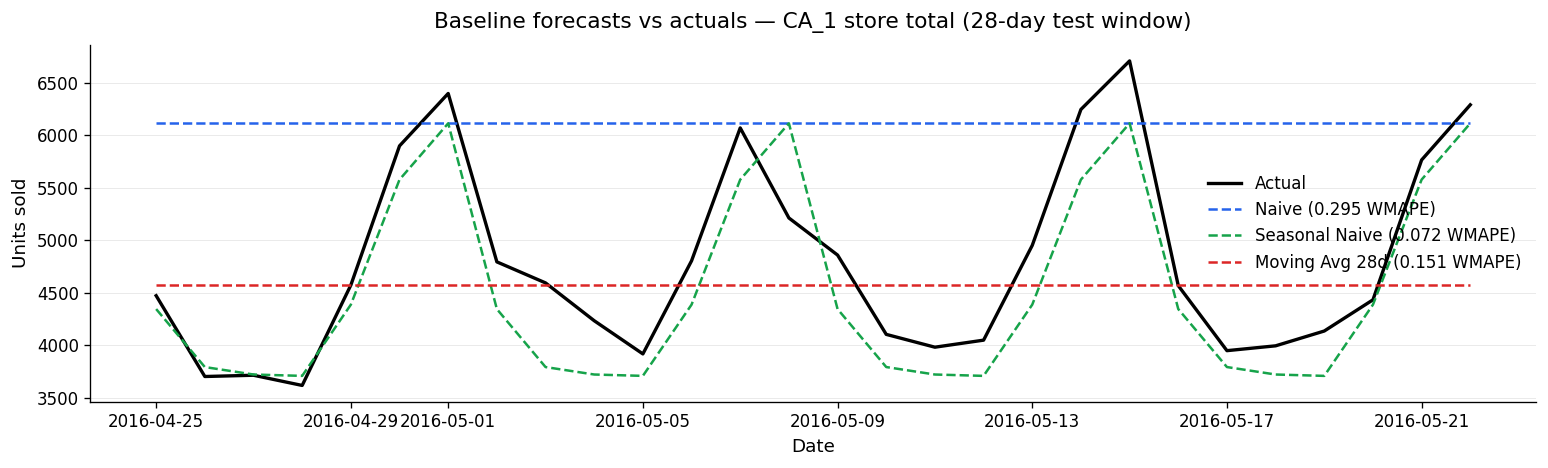

In [6]:
test_dates = test.groupby("date")["sales"].sum().index

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_dates, actual_agg, label="Actual", color="black", linewidth=2)
ax.plot(
    test_dates,
    naive_agg,
    label=f"Naive ({naive_wmape:.3f} WMAPE)",
    color=PALETTE[0],
    linewidth=1.5,
    linestyle="--",
)
ax.plot(
    test_dates,
    sn_agg,
    label=f"Seasonal Naive ({sn_wmape:.3f} WMAPE)",
    color=PALETTE[1],
    linewidth=1.5,
    linestyle="--",
)
ax.plot(
    test_dates,
    ma_agg,
    label=f"Moving Avg 28d ({ma_wmape:.3f} WMAPE)",
    color=PALETTE[2],
    linewidth=1.5,
    linestyle="--",
)

ax.set_title("Baseline forecasts vs actuals — CA_1 store total (28-day test window)")
ax.set_xlabel("Date")
ax.set_ylabel("Units sold")
ax.legend()
ax.grid(axis="y")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baselines_comparison_plot.png", dpi=150)
plt.show()

In [7]:
from forecasting.models import evaluate_baselines

metrics_df = evaluate_baselines(train, test)

print("=== Baseline metrics (store-level aggregation) ===")
print()
print(metrics_df.to_string(index=False))
print()
print("WMAPE interpretation:")
print("  0.10 = 10% of total sales volume in absolute error")
print("  Lower is better. Seasonal naive is the true floor.")
print()
print("MASE interpretation:")
print("  < 1.0 = beats seasonal naive. > 1.0 = worse than seasonal naive.")

metrics_df.to_csv(RESULTS_DIR / "baselines_metrics.csv", index=False)
print(f"\nSaved to results/baselines_metrics.csv")

=== Baseline metrics (store-level aggregation) ===

             model    wmape     mase    rmsse
             Naive 0.294736 4.103885 2.675603
SeasonalNaive(m=7) 0.071819 1.000000 0.680515
MovingAverage(28d) 0.151307 2.106794 1.557132

WMAPE interpretation:
  0.10 = 10% of total sales volume in absolute error
  Lower is better. Seasonal naive is the true floor.

MASE interpretation:
  < 1.0 = beats seasonal naive. > 1.0 = worse than seasonal naive.

Saved to results/baselines_metrics.csv


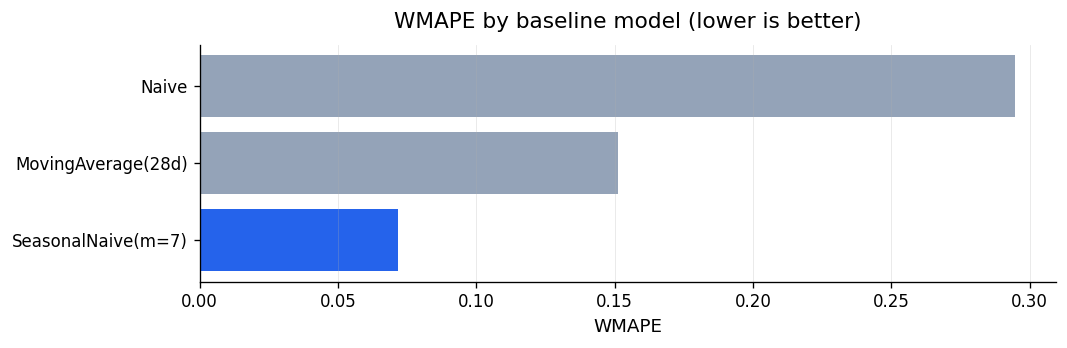

In [8]:
# Bar chart comparison
ax = plot_metrics_comparison(
    metrics_df.sort_values("wmape"),
    metric_col="wmape",
    title="WMAPE by baseline model (lower is better)",
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baselines_metrics_chart.png", dpi=150)
plt.show()

## 6. Where baselines fail — sample SKU analysis

Store-level metrics look decent because errors cancel out across thousands of
SKUs. SKU-level forecasting is much harder — this is where ML will win.

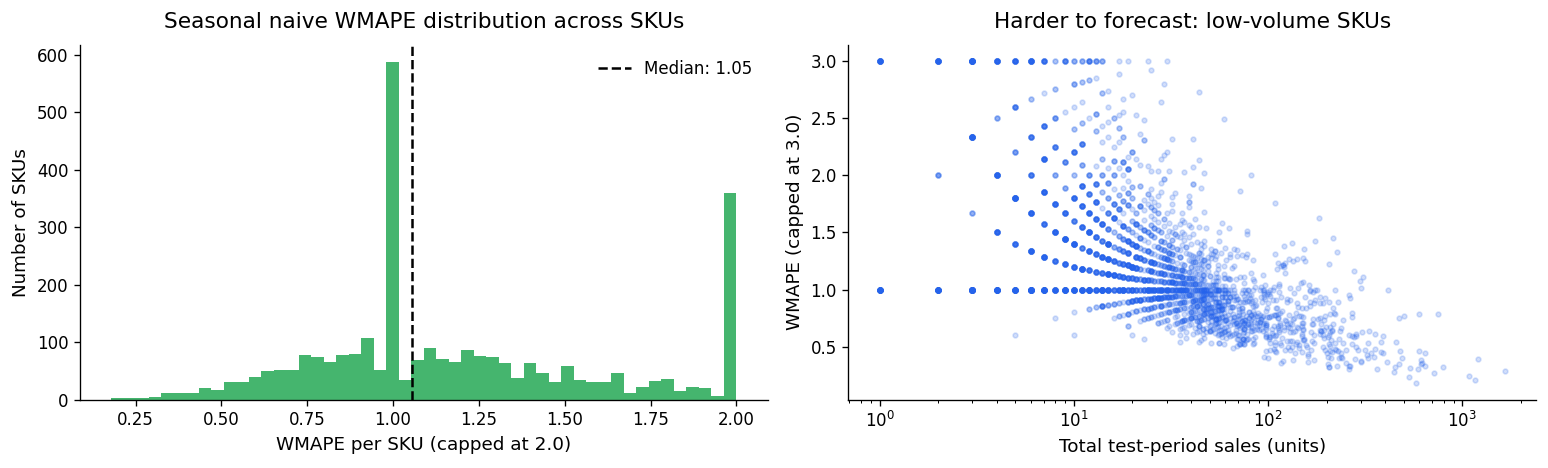

SKU WMAPE percentiles (seasonal naive):
count    2987.000
mean        1.342
std         1.509
min         0.179
25%         0.920
50%         1.054
75%         1.462
90%         2.091
95%         2.732
max        61.000


In [9]:
from commerce_ml.evaluation.forecast_metrics import wmape as compute_wmape

# WMAPE per SKU for seasonal naive
sku_metrics = []
for sku_id, group in test.groupby("id"):
    sn_sku = sn_preds[sn_preds["id"] == sku_id]["forecast"].values
    actual_sku = group["sales"].values
    if actual_sku.sum() > 0:
        w = compute_wmape(actual_sku, sn_sku)
        sku_metrics.append(
            {
                "id": sku_id,
                "wmape": w,
                "cat_id": group["cat_id"].iloc[0],
                "total_sales": int(actual_sku.sum()),
            }
        )

sku_df = pd.DataFrame(sku_metrics)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# WMAPE distribution
ax = axes[0]
ax.hist(sku_df["wmape"].clip(upper=2.0), bins=50, color=PALETTE[1], alpha=0.8)
ax.axvline(
    sku_df["wmape"].median(),
    color="black",
    linewidth=1.5,
    linestyle="--",
    label=f"Median: {sku_df['wmape'].median():.2f}",
)
ax.set_xlabel("WMAPE per SKU (capped at 2.0)")
ax.set_ylabel("Number of SKUs")
ax.set_title("Seasonal naive WMAPE distribution across SKUs")
ax.legend()

# WMAPE vs total sales
ax = axes[1]
ax.scatter(sku_df["total_sales"], sku_df["wmape"].clip(upper=3.0), alpha=0.2, s=8, color=PALETTE[0])
ax.set_xlabel("Total test-period sales (units)")
ax.set_ylabel("WMAPE (capped at 3.0)")
ax.set_title("Harder to forecast: low-volume SKUs")
ax.set_xscale("log")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "baselines_sku_level_wmape.png", dpi=150)
plt.show()

print(f"SKU WMAPE percentiles (seasonal naive):")
print(sku_df["wmape"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).round(3).to_string())

## Summary

The key takeaway: **seasonal naive is the baseline that matters**. It captures
the dominant retail pattern (day-of-week seasonality) and is nearly free to
compute. Any ML model that doesn't beat it at the SKU level isn't adding value.

The histogram above shows the challenge: high WMAPE SKUs are the ones with
low total sales (intermittent demand). The LightGBM model will need to learn
to handle these differently from high-volume, stable series.

**Next notebook:** `03_lightgbm.ipynb` — global LightGBM model with lag and calendar features.